In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pandas.core.interchange.dataframe_protocol import DataFrame

from src.util.model_utils import read_jsonl

data = read_jsonl("/Users/amir/Data/Projects/SQL_parser/data/din_bird_logs/util.jsonl")


In [3]:
metric = "mem"
rows = []
for row in data:
    ts = row['record']['time']['timestamp']
    ts = int(ts)
    util = row['record']['extra']['util']
    val = util['mem']
    rows.append({"ts": ts, metric: val})

df = pd.DataFrame(rows)
df.head()


,ts,mem
0,1741120966,1988.710938
1,1741120968,2809.343750
2,1741120969,3286.039062
3,1741120971,3701.781250
4,1741120973,3988.332031


In [4]:
refined = df.copy()
refined['ts'] = refined['ts'] - refined['ts'].min()
refined.head()


,ts,mem
0,0,1988.710938
1,2,2809.343750
2,3,3286.039062
3,5,3701.781250
4,7,3988.332031


In [10]:

def draw_range(start=0, end=len(refined)):
    filtered = refined.copy()
    filtered = filtered[(filtered['ts'] > start) & (filtered['ts'] < end)]
    plt.figure(figsize=(30, 6))
    sns.lineplot(data=filtered, x="ts", y=metric)
    plt.show()


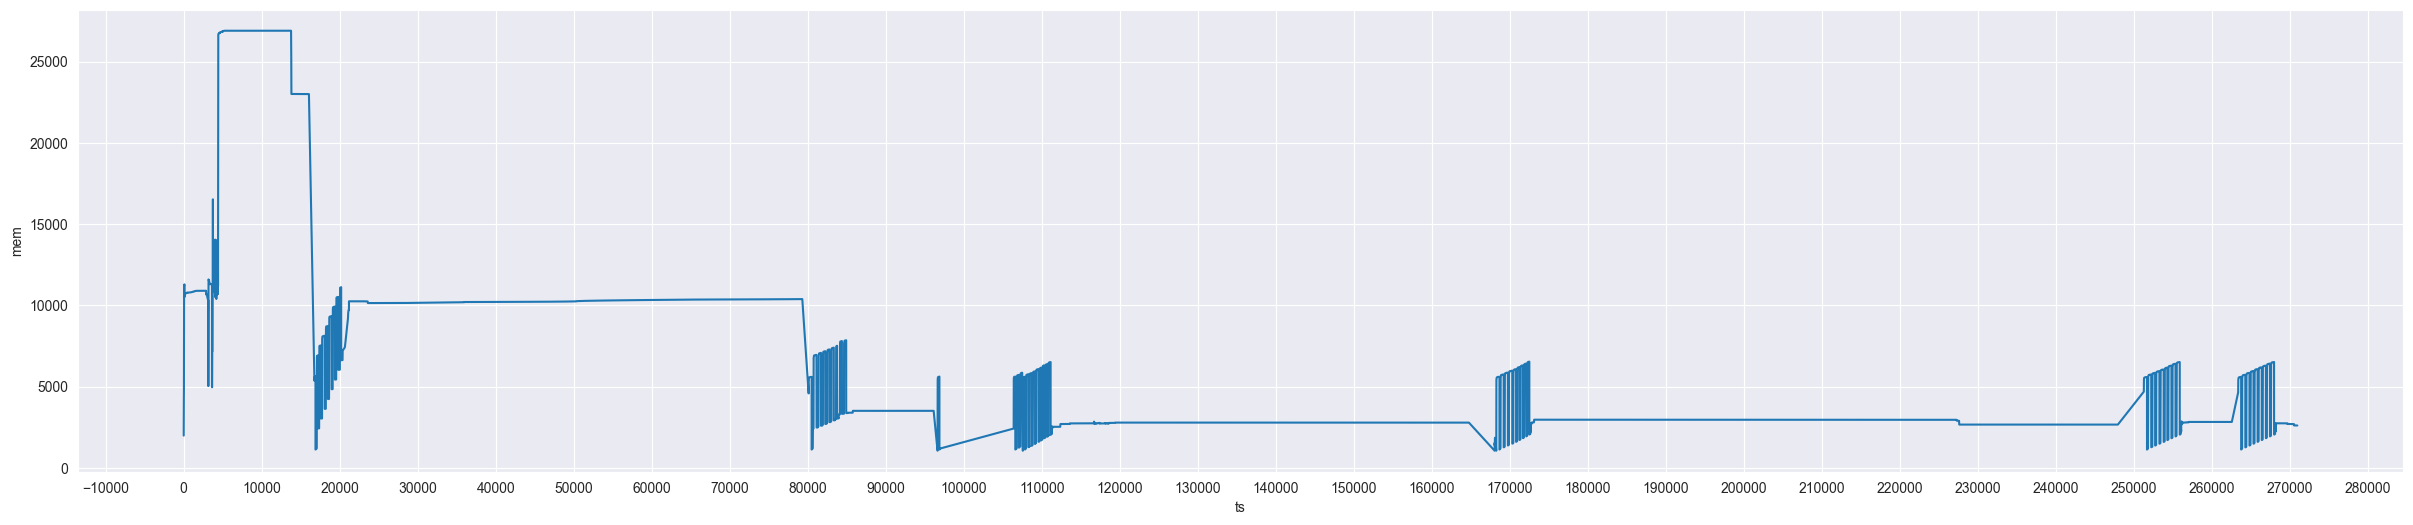

In [8]:

plt.figure(figsize=(30, 6))
sns.lineplot(data=refined, x="ts", y=metric)
plt.locator_params(axis='x', nbins=40)
plt.show()


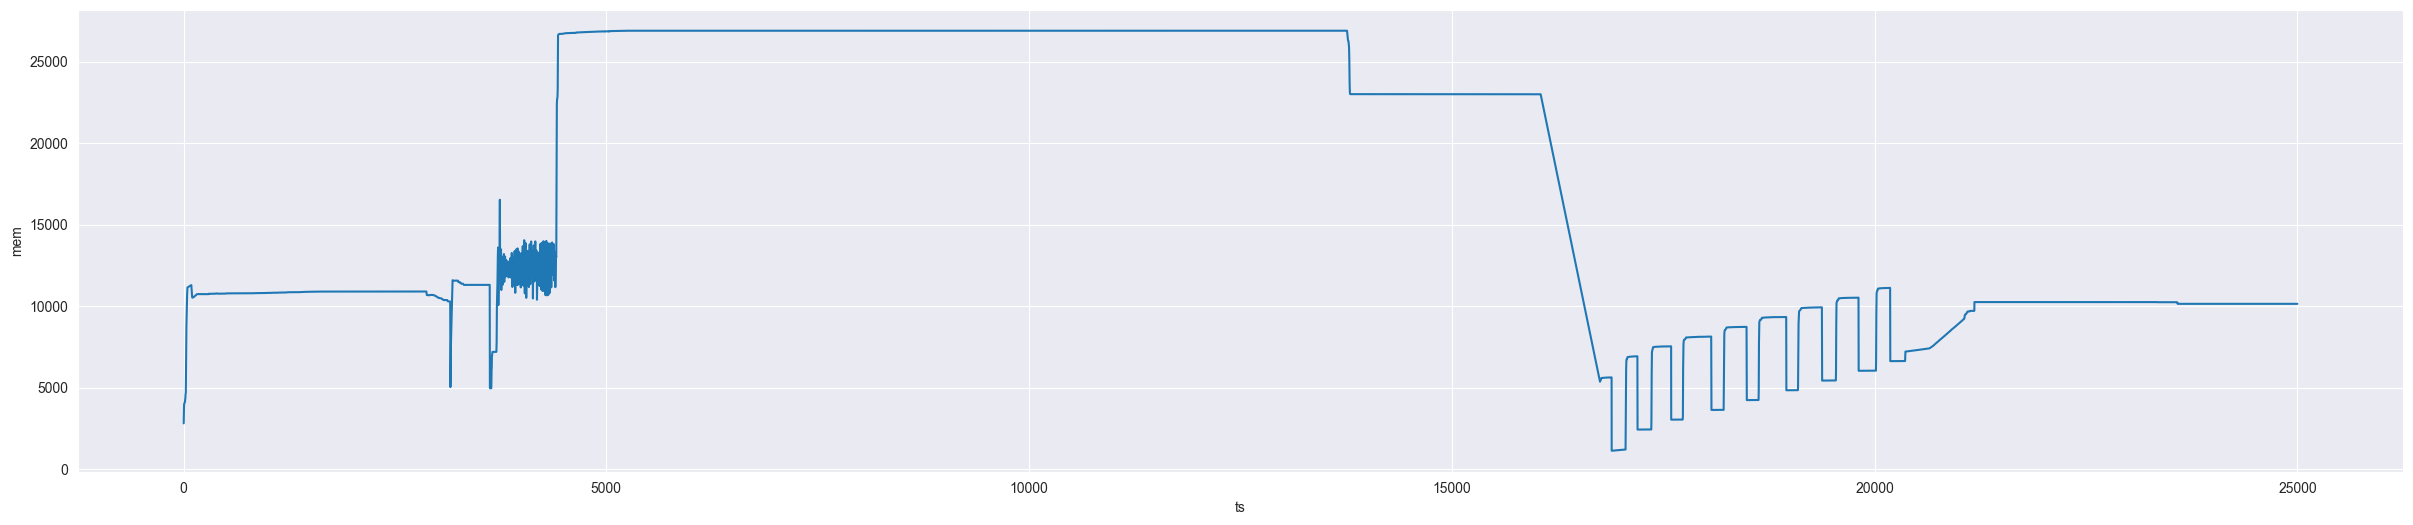